# 1. Data Understanding (Data Loading & Exploratory Data Analysis)

In [1]:
DATASET_PATH = "dataset2.csv"
TARGET_COL = None
POSITIVE_LABEL_NAME = "phishing"
NEGATIVE_LABEL_NAME = "legitimate"


In [16]:
# Import Library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)


In [3]:
df = pd.read_csv(DATASET_PATH)
print(f"Dataset berhasil dimuat: {df.shape[0]} baris, {df.shape[1]} kolom")
df.head()


Dataset berhasil dimuat: 88647 baris, 112 kolom


,qty_dot_url,qty_hyphen_url,qty_underline_url,qty_slash_url,qty_questionmark_url,qty_equal_url,qty_at_url,qty_and_url,qty_exclamation_url,qty_space_url,qty_tilde_url,qty_comma_url,qty_plus_url,qty_asterisk_url,qty_hashtag_url,qty_dollar_url,qty_percent_url,qty_tld_url,length_url,qty_dot_domain,qty_hyphen_domain,qty_underline_domain,qty_slash_domain,qty_questionmark_domain,qty_equal_domain,qty_at_domain,qty_and_domain,qty_exclamation_domain,qty_space_domain,qty_tilde_domain,qty_comma_domain,qty_plus_domain,qty_asterisk_domain,qty_hashtag_domain,qty_dollar_domain,qty_percent_domain,qty_vowels_domain,domain_length,domain_in_ip,server_client_domain,qty_dot_directory,qty_hyphen_directory,qty_underline_directory,qty_slash_directory,qty_questionmark_directory,qty_equal_directory,qty_at_directory,qty_and_directory,qty_exclamation_directory,qty_space_directory,qty_tilde_directory,qty_comma_directory,qty_plus_directory,qty_asterisk_directory,qty_hashtag_directory,qty_dollar_directory,qty_percent_directory,directory_length,qty_dot_file,qty_hyphen_file,qty_underline_file,qty_slash_file,qty_questionmark_file,qty_equal_file,qty_at_file,qty_and_file,qty_exclamation_file,qty_space_file,qty_tilde_file,qty_comma_file,qty_plus_file,qty_asterisk_file,qty_hashtag_file,qty_dollar_file,qty_percent_file,file_length,qty_dot_params,qty_hyphen_params,qty_underline_params,qty_slash_params,qty_questionmark_params,qty_equal_params,qty_at_params,qty_and_params,qty_exclamation_params,qty_space_params,qty_tilde_params,qty_comma_params,qty_plus_params,qty_asterisk_params,qty_hashtag_params,qty_dollar_params,qty_percent_params,params_length,tld_present_params,qty_params,email_in_url,time_response,domain_spf,asn_ip,time_domain_activation,time_domain_expiration,qty_ip_resolved,qty_nameservers,qty_mx_servers,ttl_hostname,tls_ssl_certificate,qty_redirects,url_google_index,domain_google_index,url_shortened,phishing
0,3,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,25,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,4,17,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,8,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,7,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,0,0.207316,0,60781,-1,-1,1,2,0,892,0,0,0,0,0,1
1,5,0,1,3,0,3,0,2,0,0,0,0,0,0,0,0,0,3,223,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,5,16,0,0,3,0,0,3,0,0,0,0,0,0,0,0,0,0,0,0,0,42,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,9,0,0,1,0,0,3,0,2,0,0,0,0,0,0,0,0,0,165,0,3,0,0.499566,-1,36024,579,150,1,2,1,9540,1,0,0,0,0,1
2,2,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,15,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,3,14,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,0,0.935901,0,4766,-1,-1,1,2,3,589,1,0,0,0,0,0
3,4,0,2,5,0,0,0,0,0,0,0,0,0,0,0,0,0,1,81,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,7,19,0,0,2,0,2,5,0,0,0,0,0,0,0,0,0,0,0,0,0,62,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,9,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,0,0.410021,0,20454,-1,-1,1,2,0,292,1,0,0,0,0,1
4,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,19,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,5,19,0,0,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,0,0.410761,0,53831,6998,306,1,2,1,3597,0,1,0,0,0,0


In [4]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 88647 entries, 0 to 88646
Columns: 112 entries, qty_dot_url to phishing
dtypes: float64(1), int64(111)
memory usage: 75.7 MB


In [5]:
if TARGET_COL is None:
    candidate_names = ["label", "Label", "class", "Class", "type", "Type",
                        "target", "Target", "phishing", "Phishing", "y", "Result", "result"]
    found = [c for c in candidate_names if c in df.columns]
    if found:
        TARGET_COL = found[0]
        print(f"Kolom target terdeteksi otomatis: '{TARGET_COL}'")
    else:
        print("Kolom target TIDAK terdeteksi otomatis.")
        print("Kolom yang tersedia:", list(df.columns))
        print(">> Silakan isi variabel TARGET_COL secara manual di cell konfigurasi di atas, lalu jalankan ulang notebook dari awal.")
else:
    print(f"Menggunakan kolom target yang ditentukan manual: '{TARGET_COL}'")

assert TARGET_COL is not None and TARGET_COL in df.columns, \
    "TARGET_COL belum valid. Cek nama kolom label pada dataset, lalu isi manual di cell konfigurasi."

Kolom target terdeteksi otomatis: 'phishing'


In [6]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

if missing.empty:
    print("Tidak ada missing value pada dataset ini.")
else:
    print("Kolom dengan missing value:")
    display(missing)

Tidak ada missing value pada dataset ini.


In [7]:
n_dup = df.duplicated().sum()

In [8]:
df.describe().T


,count,mean,std,min,25%,50%,75%,max
qty_dot_url,88647.0,2.191343,1.235636,1.0,2.0,2.0,2.0,24.0
qty_hyphen_url,88647.0,0.328810,1.119286,0.0,0.0,0.0,0.0,35.0
qty_underline_url,88647.0,0.113879,0.657767,0.0,0.0,0.0,0.0,21.0
qty_slash_url,88647.0,1.281781,1.893929,0.0,0.0,0.0,2.0,44.0
qty_questionmark_url,88647.0,0.009329,0.112568,0.0,0.0,0.0,0.0,9.0
...,...,...,...,...,...,...,...,...
qty_redirects,88647.0,0.343903,0.783892,-1.0,0.0,0.0,1.0,17.0
url_google_index,88647.0,0.001410,0.058640,-1.0,0.0,0.0,0.0,1.0
domain_google_index,88647.0,0.002019,0.063250,-1.0,0.0,0.0,0.0,1.0
url_shortened,88647.0,0.005482,0.073841,0.0,0.0,0.0,0.0,1.0


##Exploratory Data Analysis (EDA)

          Jumlah  Persentase (%)
phishing                        
0          58000           65.43
1          30647           34.57


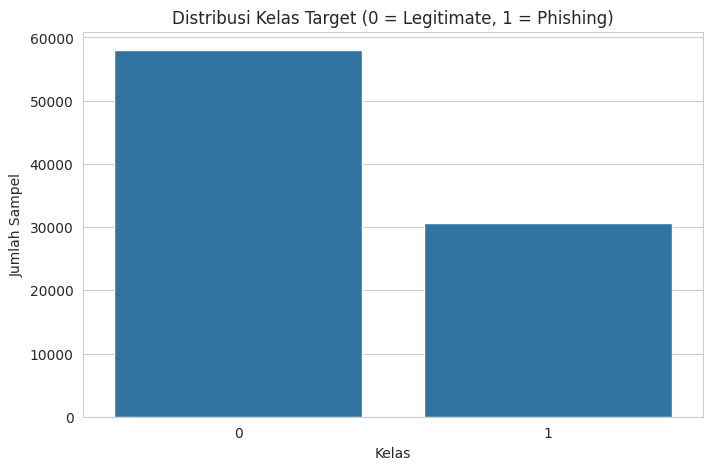


Imbalance ratio (kelas mayoritas / kelas minoritas): 1.89
>> Dataset cukup tidak seimbang. Pertimbangkan stratified split dan metrik selain accuracy (F1, ROC AUC) sebagai evaluasi utama.


In [9]:
class_counts = df[TARGET_COL].value_counts().sort_index()
class_pct = df[TARGET_COL].value_counts(normalize=True).sort_index() * 100

summary_df = pd.DataFrame({"Jumlah": class_counts, "Persentase (%)": class_pct.round(2)})
print(summary_df)

fig, ax = plt.subplots()
sns.countplot(x=TARGET_COL, data=df, ax=ax)
ax.set_title("Distribusi Kelas Target (0 = Legitimate, 1 = Phishing)")
ax.set_xlabel("Kelas")
ax.set_ylabel("Jumlah Sampel")
plt.show()

# Cek ketidakseimbangan kelas (imbalance ratio)
imbalance_ratio = class_counts.max() / class_counts.min()
print(f"\nImbalance ratio (kelas mayoritas / kelas minoritas): {imbalance_ratio:.2f}")
if imbalance_ratio > 1.5:
    print(">> Dataset cukup tidak seimbang. Pertimbangkan stratified split dan metrik selain accuracy (F1, ROC AUC) sebagai evaluasi utama.")
else:
    print(">> Dataset relatif seimbang.")

In [10]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if TARGET_COL in numeric_cols:
    numeric_cols.remove(TARGET_COL)

categorical_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()
if TARGET_COL in categorical_cols:
    categorical_cols.remove(TARGET_COL)

print(f"Jumlah fitur numerik : {len(numeric_cols)}")
print(f"Jumlah fitur kategorikal/teks : {len(categorical_cols)}")
if categorical_cols:
    print("\nKolom kategorikal/teks:", categorical_cols)

Jumlah fitur numerik : 111
Jumlah fitur kategorikal/teks : 0


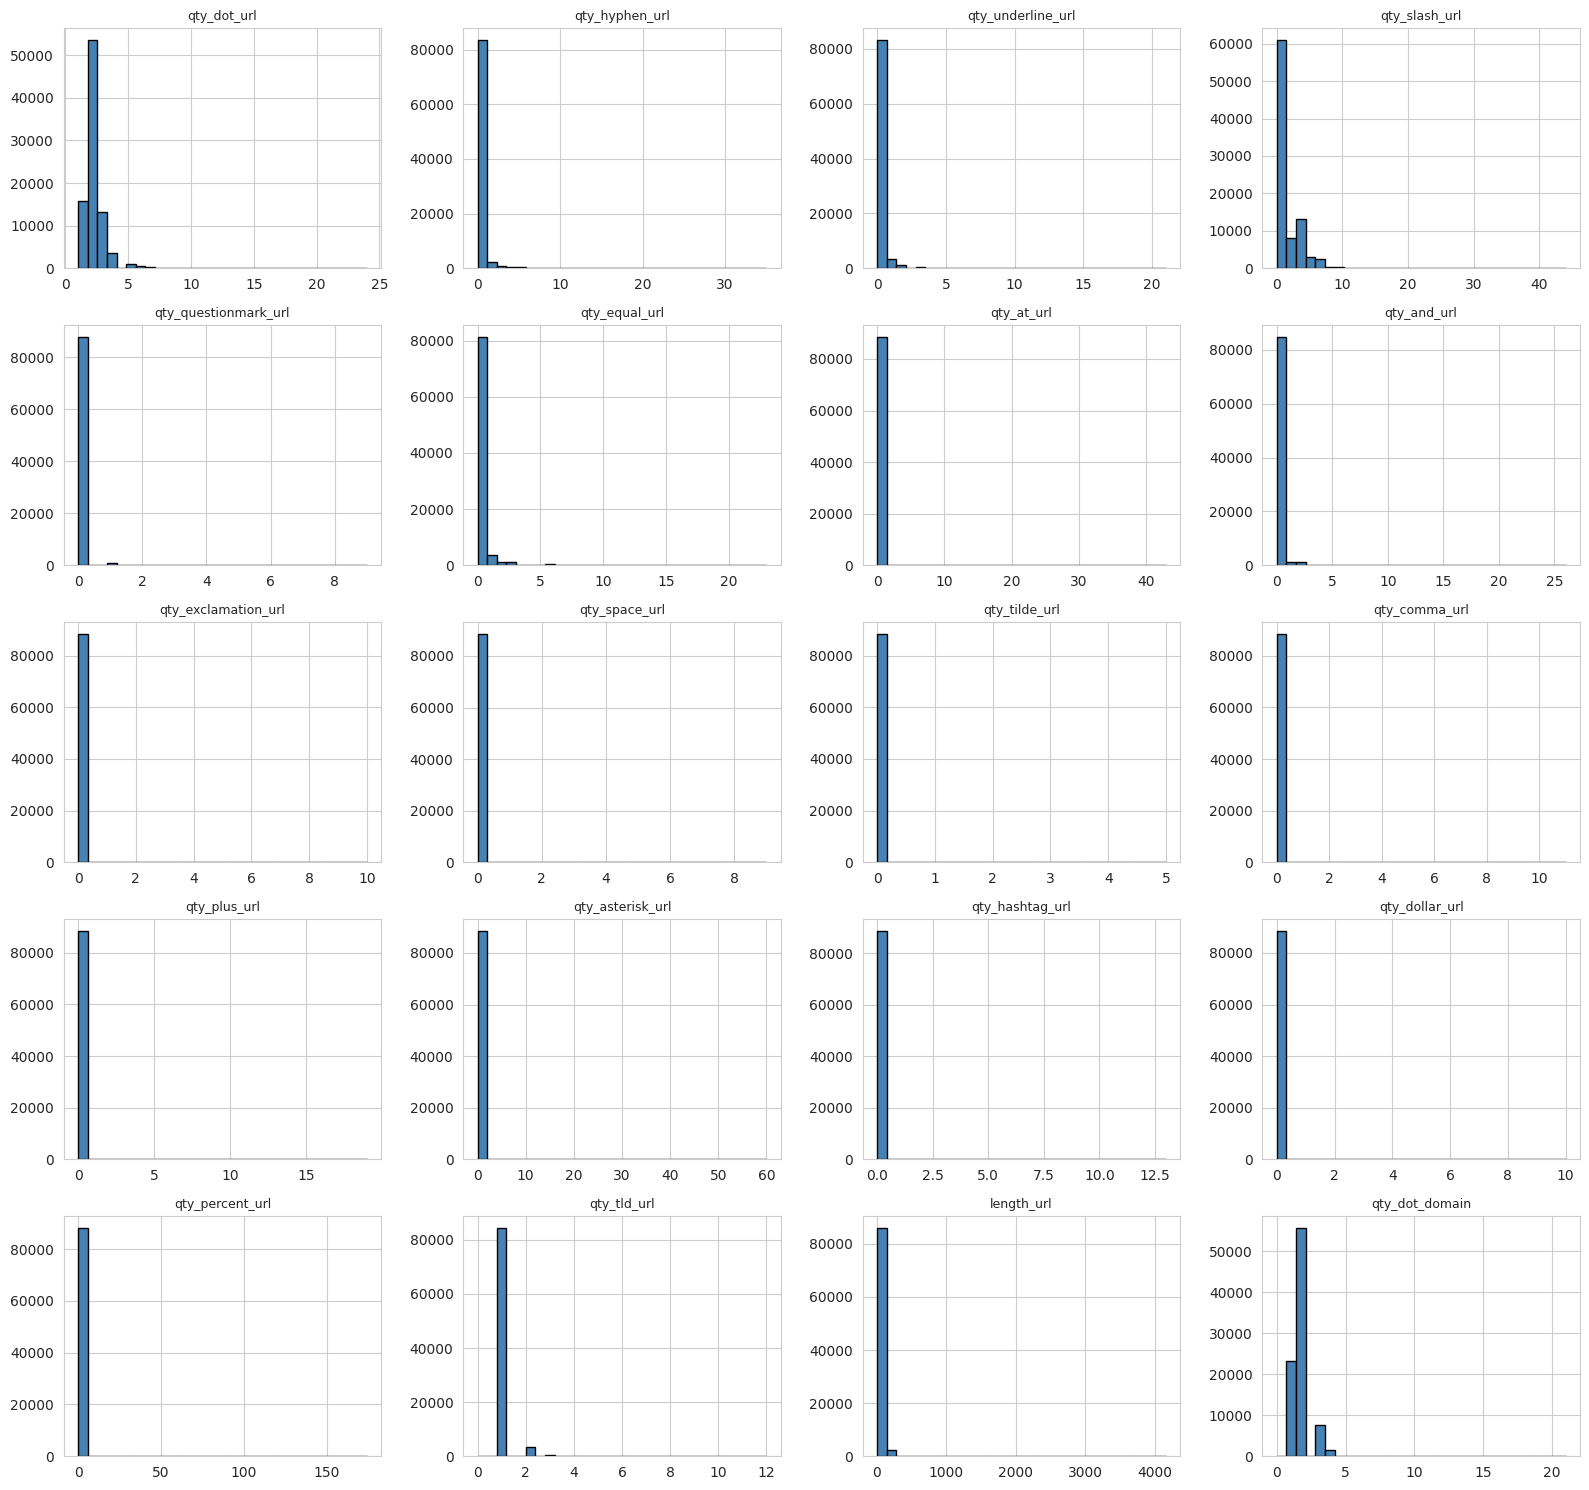

In [11]:
cols_to_plot = numeric_cols[:20]
n_cols = 4
n_rows = int(np.ceil(len(cols_to_plot) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 4, n_rows * 3))
axes = axes.flatten()

for i, col in enumerate(cols_to_plot):
    axes[i].hist(df[col].dropna(), bins=30, color="steelblue", edgecolor="black")
    axes[i].set_title(col, fontsize=9)

for j in range(len(cols_to_plot), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [12]:
outlier_summary = []

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_outlier = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_summary.append({
        "feature": col,
        "n_outlier": n_outlier,
        "pct_outlier": round(n_outlier / len(df) * 100, 2)
    })

outlier_df = pd.DataFrame(outlier_summary).sort_values("pct_outlier", ascending=False)
print("Top 15 fitur dengan proporsi outlier tertinggi (metode IQR):")
display(outlier_df.head(15))

Top 15 fitur dengan proporsi outlier tertinggi (metode IQR):


,feature,n_outlier,pct_outlier
0,qty_dot_url,34998,39.48
98,domain_spf,27765,31.32
75,file_length,21366,24.10
102,qty_ip_resolved,16841,19.00
1,qty_hyphen_url,15581,17.58
97,time_response,14199,16.02
104,qty_mx_servers,13805,15.57
101,time_domain_expiration,9298,10.49
18,length_url,8823,9.95
20,qty_hyphen_domain,8077,9.11


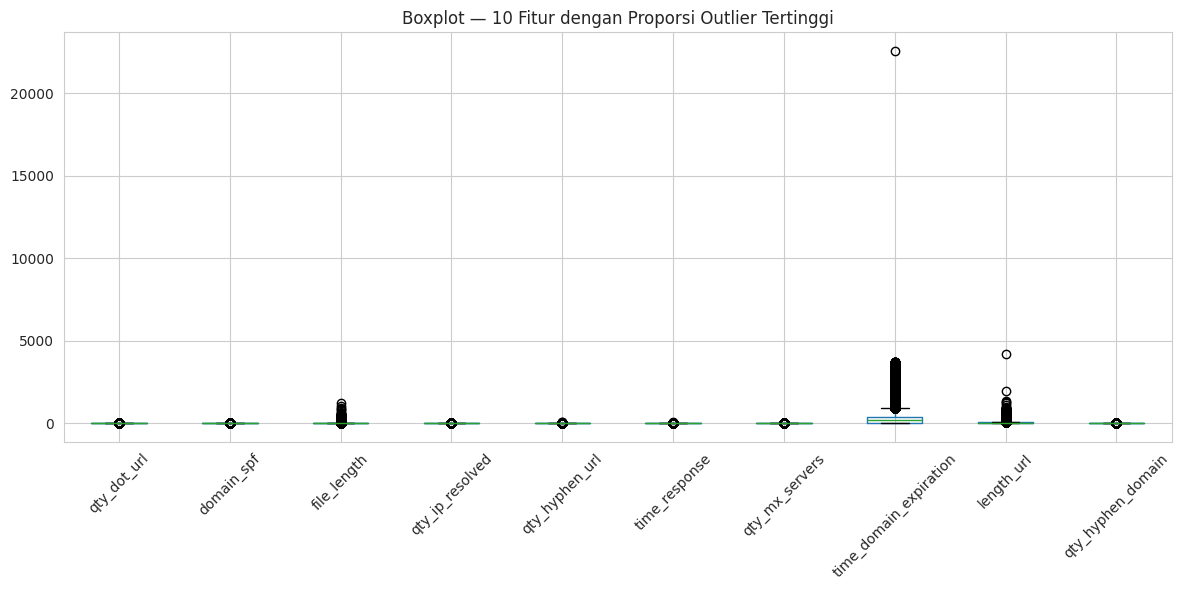

In [13]:
# Visualisasi boxplot
top_outlier_cols = outlier_df.head(10)["feature"].tolist()

fig, ax = plt.subplots(figsize=(12, 6))
df[top_outlier_cols].boxplot(ax=ax, rot=45)
ax.set_title("Boxplot — 10 Fitur dengan Proporsi Outlier Tertinggi")
plt.tight_layout()
plt.show()

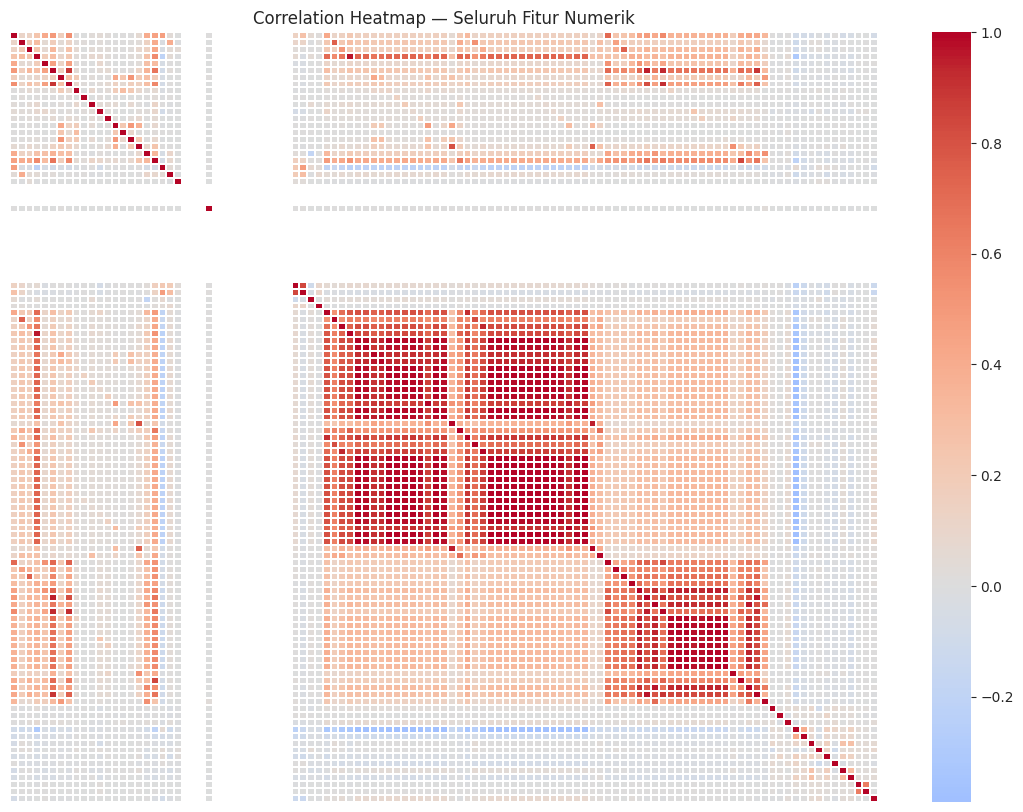

Jumlah pasangan fitur dengan korelasi > 0.9: 322


,Feature A,Feature B,Korelasi
0,qty_comma_directory,qty_comma_file,1.000
1,qty_tilde_params,qty_hashtag_params,1.000
2,qty_hashtag_file,qty_at_file,0.999
3,qty_at_file,qty_dollar_file,0.999
4,qty_at_file,qty_slash_file,0.999
5,qty_at_file,qty_hashtag_directory,0.999
6,qty_questionmark_file,qty_at_file,0.999
7,qty_at_file,qty_questionmark_directory,0.999
8,qty_tilde_file,qty_questionmark_directory,0.999
9,qty_questionmark_file,qty_tilde_file,0.999


In [14]:
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0, linewidths=0.3,
            xticklabels=False, yticklabels=False)
plt.title("Correlation Heatmap — Seluruh Fitur Numerik")
plt.show()

# Tampilkan pasangan fitur dengan korelasi sangat tinggi (>0.9) sebagai catatan
corr_pairs = corr_matrix.abs().unstack()
corr_pairs = corr_pairs[corr_pairs < 1.0].sort_values(ascending=False)
high_corr_pairs = corr_pairs[corr_pairs > 0.9]

# Hilangkan duplikat pasangan (A,B) dan (B,A)
seen = set()
unique_pairs = []
for (a, b), val in high_corr_pairs.items():
    key = tuple(sorted([a, b]))
    if key not in seen:
        seen.add(key)
        unique_pairs.append((a, b, round(val, 3)))

print(f"Jumlah pasangan fitur dengan korelasi > 0.9: {len(unique_pairs)}")
if unique_pairs:
    display(pd.DataFrame(unique_pairs, columns=["Feature A", "Feature B", "Korelasi"]).head(20))

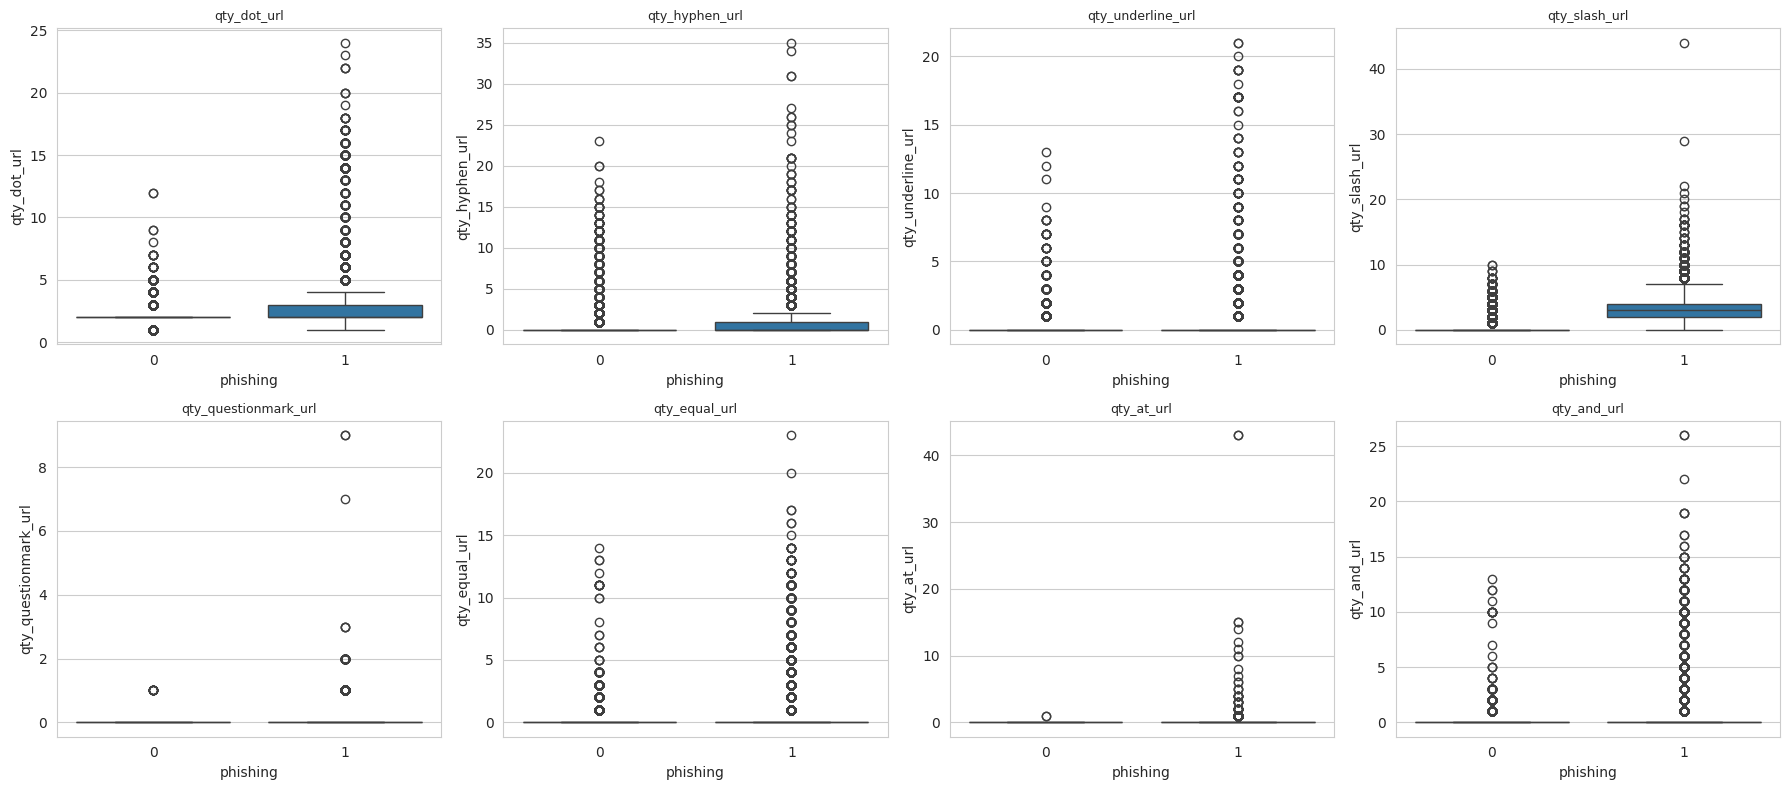

In [15]:
cols_to_compare = numeric_cols[:8]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(cols_to_compare):
    sns.boxplot(x=TARGET_COL, y=col, data=df, ax=axes[i])
    axes[i].set_title(col, fontsize=9)

for j in range(len(cols_to_compare), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# 2. Data Cleaning

In [18]:
TARGET_COL = TARGET_COL if "TARGET_COL" in globals() else None

OUTPUT_PATH = "dataset2_cleaned.csv"

NEAR_CONSTANT_THRESHOLD = 0.99
MISSING_VALUE_STRATEGY = "impute_median"

In [19]:
import pandas as pd
import numpy as np

pd.set_option("display.max_columns", None)

# Pastikan dataset dari notebook sebelumnya sudah tersedia
assert "df" in globals(), (
    "Dataset belum tersedia. Jalankan notebook Data Understanding terlebih dahulu."
)

# Salin dataset agar data asli tetap aman
df = df.copy()

# Pastikan TARGET_COL tersedia
assert TARGET_COL is not None, (
    "TARGET_COL belum ditentukan."
)

assert TARGET_COL in df.columns, (
    f"Kolom target '{TARGET_COL}' tidak ditemukan."
)

df_before = df.shape

In [20]:
n_dup = df.duplicated().sum()
print(f"Jumlah baris duplikat ditemukan: {n_dup}")

df = df.drop_duplicates().reset_index(drop=True)


Jumlah baris duplikat ditemukan: 1438


In [21]:
missing_summary = df.isnull().sum()
missing_summary = missing_summary[missing_summary > 0].sort_values(ascending=False)

if missing_summary.empty:
    print("Tidak ada missing value pada dataset ini. Lewati ke tahap berikutnya.")
else:
    print("Kolom dengan missing value:")
    display(missing_summary)
    print(f"\nStrategi yang digunakan: {MISSING_VALUE_STRATEGY}")


Tidak ada missing value pada dataset ini. Lewati ke tahap berikutnya.


In [22]:
if not missing_summary.empty:
    if MISSING_VALUE_STRATEGY == "drop_rows":
        before = len(df)
        df = df.dropna().reset_index(drop=True)
        print(f"Baris dihapus karena missing value: {before - len(df)}")

    elif MISSING_VALUE_STRATEGY == "impute_median":
        numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
        if TARGET_COL in numeric_cols:
            numeric_cols.remove(TARGET_COL)
        for col in numeric_cols:
            if df[col].isnull().sum() > 0:
                median_val = df[col].median()
                df[col] = df[col].fillna(median_val)
                print(f"Kolom '{col}': missing value diisi dengan median ({median_val:.4f})")

    elif MISSING_VALUE_STRATEGY == "impute_mode":
        for col in df.columns:
            if df[col].isnull().sum() > 0:
                mode_val = df[col].mode().iloc[0]
                df[col] = df[col].fillna(mode_val)
                print(f"Kolom '{col}': missing value diisi dengan modus ({mode_val})")

    else:
        raise ValueError(f"MISSING_VALUE_STRATEGY '{MISSING_VALUE_STRATEGY}' tidak dikenali.")

    remaining = df.isnull().sum().sum()
    print(f"\nTotal missing value tersisa setelah penanganan: {remaining}")
    assert remaining == 0, "Masih ada missing value tersisa. Cek ulang strategi penanganan."


In [23]:
#Hapus fitur nean constant
feature_cols = [c for c in df.columns if c != TARGET_COL]

constant_report = []
for col in feature_cols:
    top_freq = df[col].value_counts(normalize=True, dropna=False).iloc[0]
    constant_report.append({"feature": col, "dominant_value_ratio": round(top_freq, 4)})

constant_df = pd.DataFrame(constant_report).sort_values("dominant_value_ratio", ascending=False)

cols_to_drop = constant_df[constant_df["dominant_value_ratio"] >= NEAR_CONSTANT_THRESHOLD]["feature"].tolist()

print(f"Ambang batas near-constant: {NEAR_CONSTANT_THRESHOLD}")
print(f"Jumlah fitur yang akan dihapus karena (near-)constant: {len(cols_to_drop)}")
if cols_to_drop:
    display(constant_df[constant_df["feature"].isin(cols_to_drop)])


Ambang batas near-constant: 0.99
Jumlah fitur yang akan dihapus karena (near-)constant: 29


,feature,dominant_value_ratio
24,qty_equal_domain,1.0000
31,qty_plus_domain,1.0000
34,qty_dollar_domain,1.0000
35,qty_percent_domain,1.0000
32,qty_asterisk_domain,1.0000
33,qty_hashtag_domain,1.0000
30,qty_comma_domain,1.0000
23,qty_questionmark_domain,1.0000
28,qty_space_domain,1.0000
25,qty_at_domain,1.0000


In [24]:
if cols_to_drop:
    df = df.drop(columns=cols_to_drop)
    print(f"Fitur dihapus: {cols_to_drop}")
else:
    print("Tidak ada fitur yang perlu dihapus pada tahap ini.")

print(f"\nShape setelah menghapus fitur constant: {df.shape}")


Fitur dihapus: ['qty_equal_domain', 'qty_plus_domain', 'qty_dollar_domain', 'qty_percent_domain', 'qty_asterisk_domain', 'qty_hashtag_domain', 'qty_comma_domain', 'qty_questionmark_domain', 'qty_space_domain', 'qty_at_domain', 'qty_and_domain', 'qty_exclamation_domain', 'qty_slash_domain', 'qty_tilde_domain', 'qty_hashtag_url', 'qty_space_url', 'qty_underline_domain', 'qty_dollar_url', 'qty_asterisk_url', 'qty_comma_url', 'qty_plus_url', 'domain_in_ip', 'qty_exclamation_url', 'qty_tilde_url', 'url_google_index', 'domain_google_index', 'server_client_domain', 'url_shortened', 'qty_questionmark_url']

Shape setelah menghapus fitur constant: (87209, 83)


In [25]:
# Pastikan kolom target hanya berisi 0 dan 1 (binary classification)
unique_target_vals = df[TARGET_COL].unique()
print(f"Nilai unik pada kolom target: {unique_target_vals}")

assert set(unique_target_vals).issubset({0, 1}), \
    f"Kolom target berisi nilai selain 0/1: {unique_target_vals}. Perlu mapping manual, misalnya .map({{'phishing': 1, 'legitimate': 0}})"

# Tampilkan ringkasan tipe data
print("\nRingkasan tipe data per kolom:")
display(df.dtypes.value_counts())


Nilai unik pada kolom target: [1 0]

Ringkasan tipe data per kolom:


,count
int64,82
float64,1


In [26]:
non_negative_candidates = [c for c in df.columns if
                            any(keyword in c.lower() for keyword in ["length", "count", "num_", "jumlah", "ratio"])]

problem_cols = []
for col in non_negative_candidates:
    if pd.api.types.is_numeric_dtype(df[col]) and (df[col] < 0).any():
        problem_cols.append(col)

if problem_cols:
    print("Fitur dengan nilai negatif yang mencurigakan (perlu dicek manual):")
    for col in problem_cols:
        n_neg = (df[col] < 0).sum()
        print(f"  - {col}: {n_neg} baris bernilai negatif")
else:
    print("Tidak ditemukan nilai negatif mencurigakan pada fitur count/length/ratio.")


Fitur dengan nilai negatif yang mencurigakan (perlu dicek manual):
  - directory_length: 46323 baris bernilai negatif
  - file_length: 46323 baris bernilai negatif
  - params_length: 79846 baris bernilai negatif
  - time_domain_expiration: 24997 baris bernilai negatif


In [27]:
# Hasil Data Cleaning
print(f"Shape sebelum cleaning : {df_before[0]} baris, {df_before[1]} kolom")
print(f"Shape sesudah cleaning : {df.shape[0]} baris, {df.shape[1]} kolom")
print(f"Baris terhapus         : {df_before[0] - df.shape[0]}")
print(f"Kolom terhapus         : {df_before[1] - df.shape[1]}")
print(f"Missing value tersisa  : {df.isnull().sum().sum()}")
print(f"Duplicate tersisa      : {df.duplicated().sum()}")


Shape sebelum cleaning : 88647 baris, 112 kolom
Shape sesudah cleaning : 87209 baris, 83 kolom
Baris terhapus         : 1438
Kolom terhapus         : 29
Missing value tersisa  : 0
Duplicate tersisa      : 13


In [28]:
df.to_csv(OUTPUT_PATH, index=False)
print(f"Dataset hasil cleaning disimpan sebagai: {OUTPUT_PATH}")

Dataset hasil cleaning disimpan sebagai: dataset2_cleaned.csv
